## Business Insights and Recommendations

Questo notebook interpreta i risultati emersi nelle fasi precedenti con l'obiettivo di renderli utili dal punto di vista business.

L'analisi si concentra sui principali segnali associati al churn, sui limiti operativi del modello e sulle possibili azioni prioritarie da considerare in ottica retention.

Il notebook conclude il progetto collegando evidenze analitiche e implicazioni decisionali.

## Interpretazione del modello

Il modello finale selezionato è una Logistic Regression.

Essendo un modello interpretabile, i coefficienti stimati permettono di osservare quali variabili sono associate a una maggiore o minore probabilità di churn.

Coefficienti positivi indicano una maggiore probabilità di churn, mentre coefficienti negativi indicano una probabilità inferiore.

In questa sezione vengono analizzate le variabili che influenzano maggiormente le previsioni del modello e la loro coerenza con quanto osservato durante l’analisi esplorativa dei dati.

## Import delle librerie

In [44]:
# Manipolazione dati
import pandas as pd

# Modellazione
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

## Caricamento del dataset pulito

In [45]:
df = pd.read_csv('../data/processed/telco_clean.csv')

## Preparazione dei dati e ricostruzione del modello finale

In [46]:
X_features = df.drop(columns=['Churn'])
y_target = df['Churn']
y_target = y_target.map({'Yes': 1, 'No': 0})

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target
)

In [48]:
features_num = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
features_cat = X_train.select_dtypes(include=['object']).columns.tolist()

In [49]:
df_X_train_preprocessed = pd.DataFrame(index=X_train.index)
df_X_test_preprocessed = pd.DataFrame(index=X_test.index)

In [50]:
ss = StandardScaler()
X_train_std = ss.fit_transform(X_train[features_num])
X_test_std = ss.transform(X_test[features_num])
num_features_names = ss.get_feature_names_out(features_num)

df_X_train_preprocessed[num_features_names] = X_train_std
df_X_test_preprocessed[num_features_names] = X_test_std

In [51]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = encoder.fit_transform(X_train[features_cat])
X_test_ohe = encoder.transform(X_test[features_cat])
cat_feature_names = encoder.get_feature_names_out(features_cat)

df_X_train_preprocessed[cat_feature_names] = X_train_ohe
df_X_test_preprocessed[cat_feature_names] = X_test_ohe

In [52]:
best_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

best_model.fit(df_X_train_preprocessed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Il modello finale viene ricostruito utilizzando gli stessi parametri selezionati nel Notebook 02, al fine di poter analizzare e interpretare i coefficienti stimati.

## Analisi dei coefficienti del modello

In [53]:
coef_df = pd.DataFrame({
    'feature': df_X_train_preprocessed.columns,
    'coefficient': best_model.coef_[0]
}).sort_values('coefficient', ascending=False)

top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)

display(top_positive)
display(top_negative)

,feature,coefficient
16,InternetService_Fiber optic,0.707981
36,Contract_Month-to-month,0.657713
3,TotalCharges,0.489698
35,StreamingMovies_Yes,0.275392
32,StreamingTV_Yes,0.262166
43,PaymentMethod_Electronic check,0.240275
18,OnlineSecurity_No,0.199030
27,TechSupport_No,0.165519
14,MultipleLines_Yes,0.132843
26,DeviceProtection_Yes,0.074190


,feature,coefficient
19,OnlineSecurity_No internet service,-0.275403
17,InternetService_No,-0.275403
34,StreamingMovies_No internet service,-0.275403
31,StreamingTV_No internet service,-0.275403
22,OnlineBackup_No internet service,-0.275403
25,DeviceProtection_No internet service,-0.275403
15,InternetService_DSL,-0.622465
2,MonthlyCharges,-0.676114
38,Contract_Two year,-0.775518
1,tenure,-1.154434


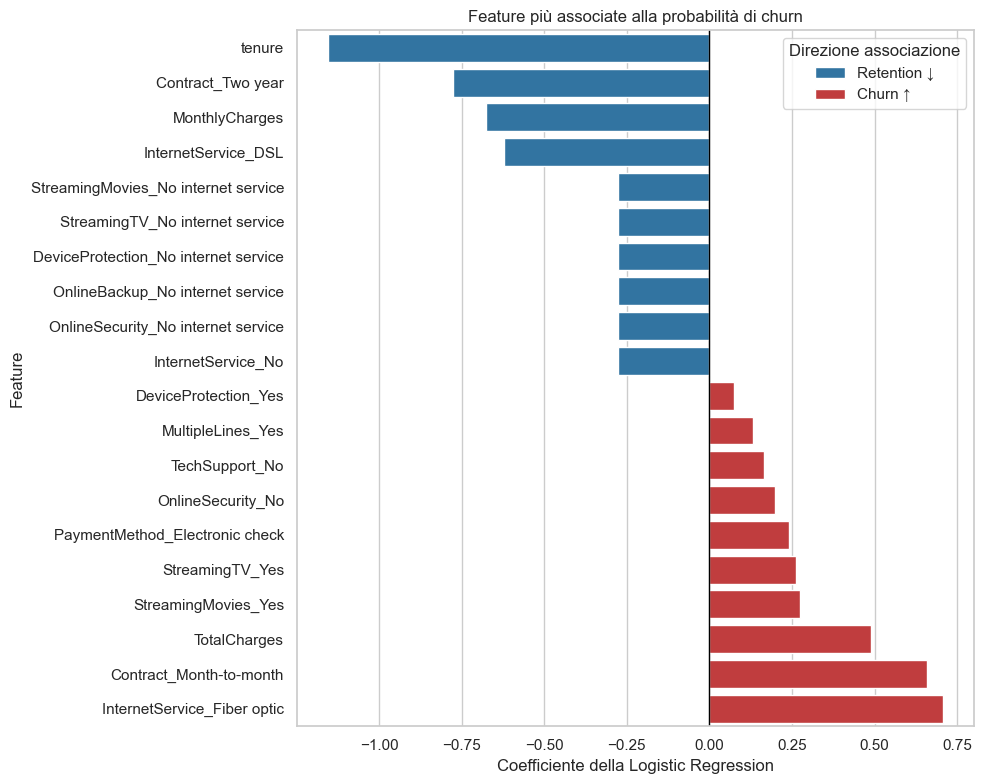

In [54]:
sns.set_theme(style='whitegrid')

coef_plot_df = pd.concat([
    coef_df.head(10),
    coef_df.tail(10)
]).sort_values('coefficient')

coef_plot_df['direction'] = coef_plot_df['coefficient'].apply(
    lambda x: 'Churn ↑' if x > 0 else 'Retention ↓'
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=coef_plot_df,
    x='coefficient',
    y='feature',
    hue='direction',
    dodge=False,
    palette={
        'Churn ↑': '#d62728',
        'Retention ↓': '#1f77b4'
    }
)

plt.axvline(0, color='black', linewidth=1)
plt.title('Feature più associate alla probabilità di churn')
plt.xlabel('Coefficiente della Logistic Regression')
plt.ylabel('Feature')
plt.legend(title='Direzione associazione')
plt.tight_layout()
plt.show()

In [55]:
# Esporta le variabili più rilevanti per una visualizzazione sintetica dei coefficienti
coef_plot_df.to_csv('../tableau/coefficients_tableau.csv', index=False)

### Lettura dei coefficienti

L’analisi dei coefficienti evidenzia alcune variabili associate a una maggiore o minore probabilità di churn.

Tra le associazioni positive più evidenti emergono il contratto `Month-to-month` e `InternetService_Fiber optic`, coerenti con profili più esposti. Variabili come `TotalCharges` e i servizi di streaming mostrano anch’esse un’associazione positiva, ma sono meno direttamente interpretabili in quanto legate alla combinazione di servizi.

Tra le associazioni negative più solide emergono tenure e il contratto `Two year`, indicativi di maggiore stabilità. Anche `InternetService_DSL` e l’assenza di internet (DeviceProtection) risultano associati a minore churn.

`MonthlyCharges` mostra un effetto negativo, ma va interpretato con cautela poiché riflette indirettamente i servizi attivi.

Nel complesso, i risultati sono coerenti con l’EDA: contratti lunghi e maggiore permanenza riducono il churn, mentre il contratto mensile è associato a maggiore rischio. Le variabili economiche e di servizio indicano associazioni utili al modello, ma non implicano causalità.

## Error analysis

Per comprendere meglio i limiti operativi del modello, vengono analizzati i casi di errore nelle previsioni sul test set.

In particolare, l’attenzione è rivolta ai falsi positivi e ai falsi negativi, al fine di individuare eventuali pattern ricorrenti nei casi in cui il modello non riesce a prevedere correttamente il churn.

#### Previsione Test

In [56]:
y_pred = best_model.predict(df_X_test_preprocessed)

#### Dataset reale e previsto

In [57]:
error_df = X_test.copy()

error_df['actual_churn'] = y_test
error_df['predicted_churn'] = y_pred

#### Falso positivo

In [58]:
false_positive = error_df[
    (error_df['actual_churn'] == 0) &
    (error_df['predicted_churn'] == 1)
]

#### Falso negativo

In [59]:
false_negative = error_df[
    (error_df['actual_churn'] == 1) &
    (error_df['predicted_churn'] == 0)
]

#### Conteggio errori

In [60]:
print('False positives:', len(false_positive))
print('False negatives:', len(false_negative))

False positives: 288
False negatives: 81


Il conteggio degli errori mostra quanti casi il modello classifica in modo errato nel test set, distinguendo tra falsi positivi e falsi negativi.  
Nel passo successivo vengono analizzate alcune variabili chiave per verificare se nei casi di errore emergono pattern ricorrenti.

### Tenure

In [61]:
false_positive['tenure'].describe()

count    288.000000
mean      19.750000
std       17.002357
min        1.000000
25%        6.000000
50%       16.000000
75%       29.000000
max       70.000000
Name: tenure, dtype: float64

In [62]:
false_negative['tenure'].describe()

count    81.000000
mean     28.666667
std      24.158849
min       1.000000
25%       4.000000
50%      28.000000
75%      49.000000
max      72.000000
Name: tenure, dtype: float64

### Contract

In [63]:
false_positive['Contract'].value_counts(normalize=True).round(3)

Contract
Month-to-month    0.931
One year          0.069
Name: proportion, dtype: float64

In [64]:
false_negative['Contract'].value_counts(normalize=True).round(3)

Contract
Month-to-month    0.543
One year          0.346
Two year          0.111
Name: proportion, dtype: float64

### Sintesi dell'error analysis

L’analisi degli errori mostra differenze nei profili dei clienti classificati in modo errato.

I falsi positivi sono concentrati soprattutto su clienti con tenure più bassa e contratti `Month-to-month`. I falsi negativi coinvolgono invece clienti con tenure mediamente più alta e una maggiore presenza di contratti `One year` e `Two year`.

Questo suggerisce che il modello tende a sovrastimare il rischio di churn nei profili più tipicamente associati all’abbandono, mentre fatica maggiormente a intercettare alcuni churn reali in profili meno evidenti.

## Segmenti più esposti al churn

Dall’analisi emergono alcuni profili cliente che risultano più esposti al churn.

Il primo segmento è rappresentato dai clienti con contratto `Month-to-month`, che mostrano una maggiore associazione con l’abbandono sia nell’analisi esplorativa sia nei coefficienti del modello.

Un secondo segmento rilevante riguarda i clienti con `tenure` più bassa, che appaiono più vulnerabili nelle fasi iniziali della relazione con l’azienda.

Infine, anche la presenza di `InternetService_Fiber optic` risulta associata a una maggiore probabilità di churn, suggerendo un possibile profilo di rischio legato a questa tipologia di servizio.

## Segmenti più stabili

Accanto ai segmenti più esposti, emergono anche profili che risultano più stabili nel tempo.

Tra questi rientrano soprattutto i clienti con `tenure` più alta e quelli con contratto `Two year`, che mostrano una minore associazione con il churn.

Anche la presenza di `InternetService_DSL` risulta associata a una probabilità di churn inferiore, suggerendo un profilo mediamente più stabile rispetto ad altri segmenti osservati.

## Implicazioni operative

I risultati suggeriscono alcune possibili implicazioni operative per la gestione della retention.

In primo luogo, i clienti con contratto `Month-to-month` rappresentano un segmento particolarmente esposto al churn e potrebbero essere monitorati con maggiore attenzione.

In secondo luogo, i clienti con `tenure` più bassa appaiono più vulnerabili nelle fasi iniziali, suggerendo l’importanza di prestare maggiore attenzione ai clienti nei primi mesi di utilizzo del servizio.

Infine, la maggiore stabilità osservata nei contratti di durata più lunga potrebbe indicare il potenziale valore di strategie volte a incentivare il passaggio da contratti mensili a formule annuali o biennali.

## Limiti dell’analisi

I risultati ottenuti devono essere interpretati tenendo conto di alcuni limiti.

In primo luogo, il modello individua associazioni tra variabili e churn, ma non consente di stabilire relazioni causali.

In secondo luogo, l’analisi è basata su uno specifico dataset e i risultati potrebbero non essere direttamente generalizzabili ad altri contesti o mercati.

Infine, il dataset utilizzato non include tutte le possibili informazioni che possono influenzare il churn. Alcuni fattori rilevanti per l’abbandono del cliente potrebbero quindi non essere rappresentati nei dati disponibili, limitando la capacità del modello di spiegare completamente il fenomeno.

## Conclusioni

L’analisi ha permesso di individuare alcuni pattern ricorrenti associati al churn.

- I clienti con contratto `Month-to-month` e `tenure` più bassa risultano più esposti al churn.
- I clienti con `tenure` più alta e contratti di durata maggiore mostrano una maggiore stabilità.
- Il modello riconosce bene i profili più tipicamente associati al churn, mentre tende a commettere più errori nei profili meno evidenti.

Nel complesso, l’analisi consente di individuare segmenti di clientela su cui concentrare maggiore attenzione nelle strategie di retention.